In [17]:
from analysis import *

In [18]:
from pathlib import Path

filename="final/normal.out"

all_events = []
dumps = []

with open(filename) as f:
    for line in f:
        if "DUMP" in line: 
            continue
        else:
            all_events.append(parse_line(line))
        
all_events = sorted(all_events, key=lambda x: x['time'])

    

In [19]:
# Find the first repair start after 10 seconds and its corresponding repair end. Get the events for the surrounding 1 seconds

start_time = all_events[0]['time'] + datetime.timedelta(seconds=10)


aligns = list(filter(lambda x: x['time'] > start_time and x['event'] == 'align', all_events))

print(len([x for x in aligns]))

start_time = aligns[0]["time"] - datetime.timedelta(seconds=0.3)
end_time = aligns[1]["time"] + datetime.timedelta(seconds=0.3)

events = list(filter(lambda x: x['time'] > start_time and x['time'] < end_time, all_events))

for e in events:
    e['t'] = (e['time'] - start_time).total_seconds()

12


In [20]:
cp_starts = [x for x in events if x["event"] == 'checkpoint_start']
cp_ends = [x for x in events if x["event"] == 'checkpoint_end']
aligns = [x for x in events if x["event"] == 'align']


print([x["t"] for x in cp_starts])
print([x["t"] for x in cp_ends])
print([x["t"] for x in aligns])



[0.033204, 0.033345, 0.033361, 0.033875, 0.657631, 0.657733, 0.657906, 0.658062]
[0.100331, 0.103074, 0.103648, 0.724782, 0.727501, 0.727801]
[0.3, 0.815153]


[{'event': 'spec_execute', 'replica_id': 3, 'seq': 20000, 'client_id': 1, 'client_seq': 2892, 'round': 8, 'digest': '6d6f116b', 'queued': 0, 'time': datetime.datetime(1900, 1, 1, 21, 11, 40, 478672), 't': 0.033165}, {'event': 'spec_execute', 'replica_id': 0, 'seq': 20000, 'client_id': 7, 'client_seq': 1962, 'round': 8, 'digest': '57dc6838', 'queued': 0, 'time': datetime.datetime(1900, 1, 1, 21, 11, 40, 478819), 't': 0.033312}, {'event': 'spec_execute', 'replica_id': 2, 'seq': 20000, 'client_id': 1, 'client_seq': 2892, 'round': 8, 'digest': '6d6f116b', 'queued': 0, 'time': datetime.datetime(1900, 1, 1, 21, 11, 40, 478834), 't': 0.033327}, {'event': 'spec_execute', 'replica_id': 1, 'seq': 20000, 'client_id': 1, 'client_seq': 2892, 'round': 8, 'digest': '6d6f116b', 'queued': 0, 'time': datetime.datetime(1900, 1, 1, 21, 11, 40, 479358), 't': 0.033851}, {'event': 'spec_execute', 'replica_id': 3, 'seq': 21000, 'client_id': 1, 'client_seq': 3017, 'round': 8, 'digest': 'a97ab119', 'queued': 0,

StopIteration: 

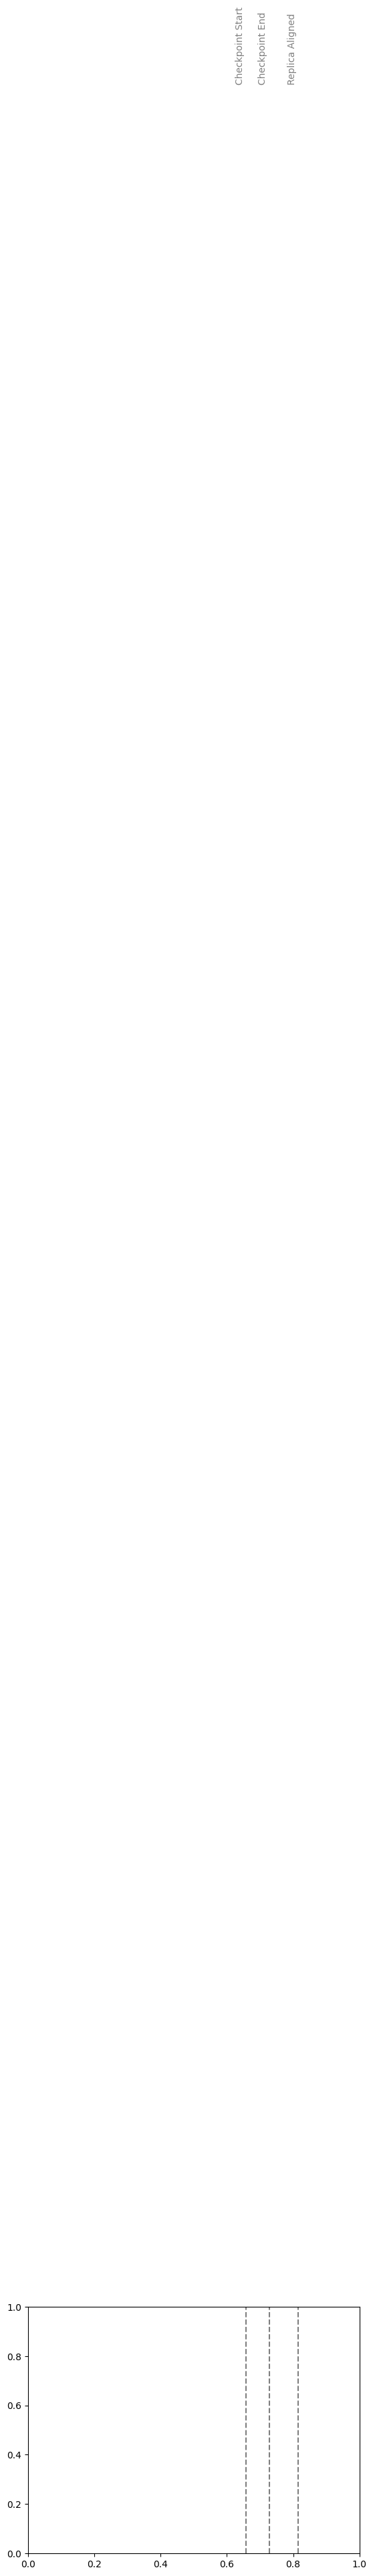

In [28]:
import matplotlib.pyplot as plt
from collections import defaultdict

# Filter commit events
commit_events = [e for e in events if e["event"] == "commit" and e["client_id"] == 0]

# Extract data
ts = [e["t"] for e in commit_events]               # use 't' instead of 'time'
latencies = [e["latency"] /1000 for e in commit_events]



def commit_color(e):
    if e["path"] == "fast":
        return "c" if e["queued"] == 1 else "g"
    elif e["path"] == "normal":
        return "b"

colors = [commit_color(e) for e in commit_events]


text_y = 10

t_start = cp_starts[-1]["t"]
plt.axvline(x=t_start, color='gray', linestyle='--')
plt.text(t_start - 0.005, text_y, 'Checkpoint Start', color='gray', rotation=90, va='bottom', ha='right')

t_end = cp_ends[-1]["t"]
plt.axvline(x=t_end, color='gray', linestyle='--')
plt.text(t_end - 0.005, text_y, 'Checkpoint End', color='gray', rotation=90, va='bottom', ha='right')

t_align = aligns[-1]["t"]
plt.axvline(x=t_align, color='gray', linestyle='--')
plt.text(t_align - 0.005, text_y, 'Replica Aligned', color='gray', rotation=90, va='bottom', ha='right')

# Cheat here, every 100 ops is diverged, find first commmit that is mod 100

c_div = (x for x in events if x["event"] == "spec_execute" and x["seq"] % 1000 == 0)
print(list(c_div))
t_div = next(c_div)["t"]

plt.axvline(x=t_div, color='gray', linestyle='--')
plt.text(t_div - 0.005, text_y, 'Replica Diverged', color='gray', rotation=90, va='bottom', ha='right')


plt.ylim(bottom=0, top=200)

# Create the scatter plot
plt.scatter(ts, latencies, c=colors, alpha=0.5)

# Labels and title
plt.xlabel("Time (t)")
plt.ylabel("Latency (ms)")
plt.title("Latency of Commit Events Over Time")

plt.tight_layout()
plt.show()


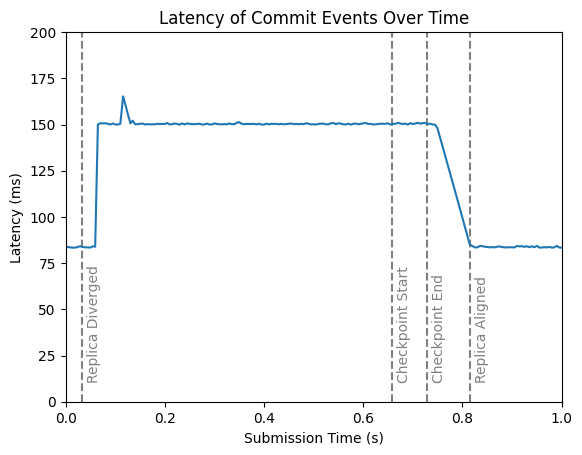

In [22]:
cs = [x for x in commit_events if x["client_id"] == 0]

start_times = [x["time"].timestamp() - x["latency"] / 10**6 for x in cs]
min_t = min(start_times)

starts = [t - min_t for t in start_times] 

data = list(zip(starts, cs))
data = sorted(data, key=lambda t: t[0])

latencies = [(t, x["latency"] / 1000) for t, x in data]


text_y = 10

plt.axvline(x=t_align, color='gray', linestyle='--')
plt.text(t_align + 0.01, text_y, 'Replica Aligned', color='gray', rotation=90, va='bottom', ha='left')

plt.axvline(x=t_div, color='gray', linestyle='--')
plt.text(t_div + 0.01, text_y, 'Replica Diverged', color='gray', rotation=90, va='bottom', ha='left')



plt.axvline(x=t_start, color='gray', linestyle='--')
plt.text(t_start + 0.01, text_y, 'Checkpoint Start', color='gray', rotation=90, va='bottom', ha='left')

plt.axvline(x=t_end, color='gray', linestyle='--')
plt.text(t_end + 0.01, text_y, 'Checkpoint End', color='gray', rotation=90, va='bottom', ha='left')


plt.xlabel("Submission Time (s)")
plt.ylabel("Latency (ms)")
plt.title("Latency of Commit Events Over Time")

times, latencies = zip(*latencies)
plt.ylim(bottom=0, top=200)
plt.xlim(left=0, right=1)

plt.plot(times, latencies)
